In [127]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from normalizing_flow import GoalDensityEstimator

device = "cuda:0"

# 导入 vx, vy 数据
path_1 = "/home/jiajun_hu/Documents/fb_hw/exp_local/fb_mod/Isaac-Flat-Unitree-Go2-Rnd-full-FB-v0/F34_B10_NF_2D/2026-02-18_02-18/models/replay_buffer_step_50000.pt"
path_2 = "/home/jiajun_hu/Documents/fb_hw/exp_local/fb_mod/Isaac-Flat-Unitree-Go2-Rnd-full-FB-v0/F34_B10_NF_2D/2026-02-18_02-18/models/replay_buffer_step_300000.pt"

goal_full_1 = torch.load(path_1)["goal"][:, :2]  # 只取 vx, vy 两维
goal_1 = goal_full_1[:10000, :]                  # 只取部分数据

goal_full_2 = torch.load(path_2)["goal"][:, :2]  # 只取 vx, vy 两维
goal_2 = goal_full_2[:10000, :]                  # 只取部分数据


# 训练 NF
estimator = GoalDensityEstimator(
    goal_dim=2,
    num_layers=10,
    hidden_dim=128,
    # beta=1.0,
    beta=2.0,
    device=device,
)

# estimator = GoalDensityEstimator(
#     goal_dim=2,
#     num_layers=6,
#     hidden_dim=64,
#     # beta=1.0,
#     beta=2.0,
#     device=device,
# )

# 逆采样测试
estimator.update(goal_1)
losses = estimator.fit(num_epochs=30, batch_size=256, lr=1e-3)


In [128]:
def PLOT_REWARD(x,y,r,sort=False, **kwargs):
    # 格式转化
    if isinstance(x, torch.Tensor):
        x = x.cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()
    if isinstance(r, torch.Tensor):
        r = r.cpu().numpy()
    
    if sort:
        sort_index = np.argsort(r)
        x = x[sort_index]
        y = y[sort_index]
        r = r[sort_index]

    s      = kwargs.pop('s', 1.5)
    title  = kwargs.pop('title', None)
    xlabel = kwargs.pop('xlabel', None)
    ylabel = kwargs.pop('ylabel', None)
    xlim   = kwargs.pop('xlim', None)
    ylim   = kwargs.pop('ylim', None)
    bar    = kwargs.pop('bar', "reward")

     
    plt.figure()
    plt.scatter(x, y, c=r, cmap='viridis', s=s)
    plt.axis('equal')
    plt.colorbar(label=bar)
    plt.xlim(xlim if xlim is not None else (np.min(x), np.max(x)))
    plt.ylim(ylim if ylim is not None else (np.min(y), np.max(y)))

    plt.grid(True, linestyle='--', alpha=0.3)

    if title is not None:
        plt.title(title)
    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)

def PLOT_DENSITY(x, y, radius=None, k_neighbors=50, **kwargs):

    from scipy.spatial import KDTree
    
    # 格式转化
    if isinstance(x, torch.Tensor):
        x = x.cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()

    x = np.asarray(x).ravel() # flatten to 1D
    y = np.asarray(y).ravel() # flatten to 1D

    # 计算每个点的局部密度
    points = np.column_stack([x, y])
    tree = KDTree(points)
    
    if radius is not None:
        # 使用半径搜索
        density = np.array([len(tree.query_ball_point(point, radius)) for point in points])
    else:
        # 使用k近邻
        density = np.ones(len(points)) * k_neighbors
        # 可选：计算到第k个邻居的平均距离的倒数作为密度
        distances, _ = tree.query(points, k=k_neighbors+1)
        density = 1.0 / (np.mean(distances[:, 1:], axis=1) + 1e-8)
    
    # 使用 PLOT_REWARD 绘制
    PLOT_REWARD(x, y, density, sort=True, **kwargs)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


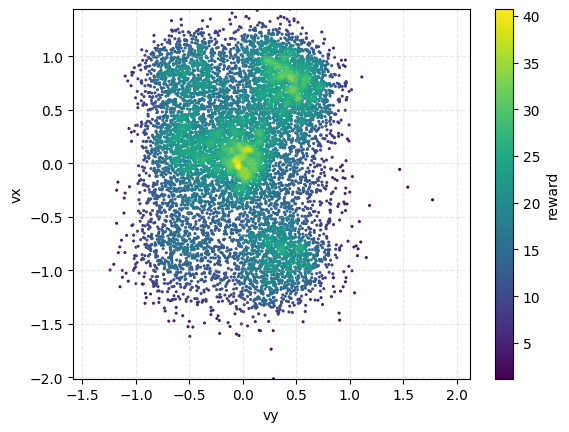

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


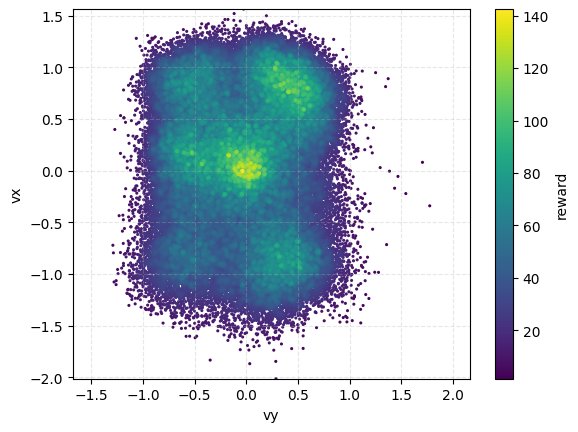

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


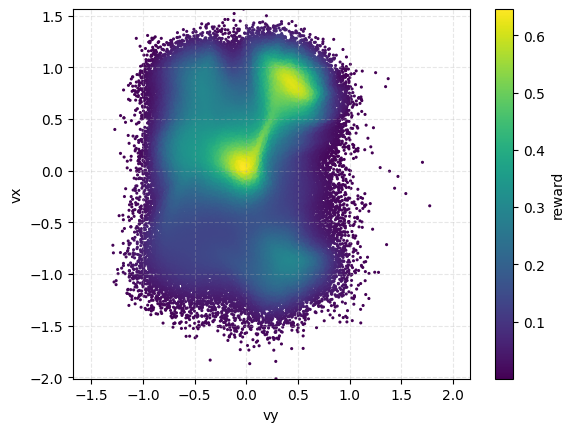

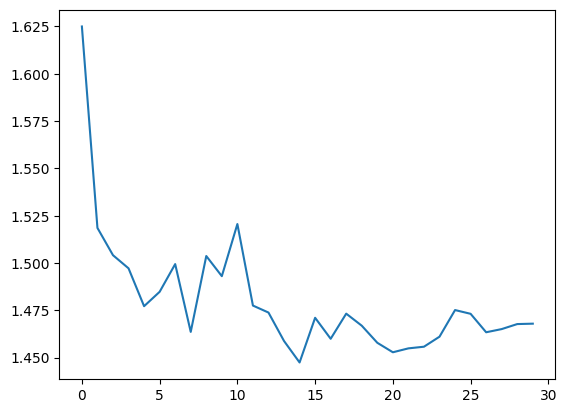

In [129]:
PLOT_DENSITY(goal_1[:, 1],  # vy
             goal_1[:, 0],  #
             xlabel="vy",
             ylabel="vx",)

PLOT_DENSITY(goal_full_1[:, 1],  # vy
             goal_full_1[:, 0],  #
             xlabel="vy",
             ylabel="vx",)

log_prob = estimator.log_prob(goal_full_1)
prob = torch.exp(log_prob)

PLOT_REWARD(goal_full_1[:, 1],  # vy
            goal_full_1[:, 0],  # vx
            prob,
            xlabel="vy",
            ylabel="vx",)

plt.figure()
plt.plot(losses)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


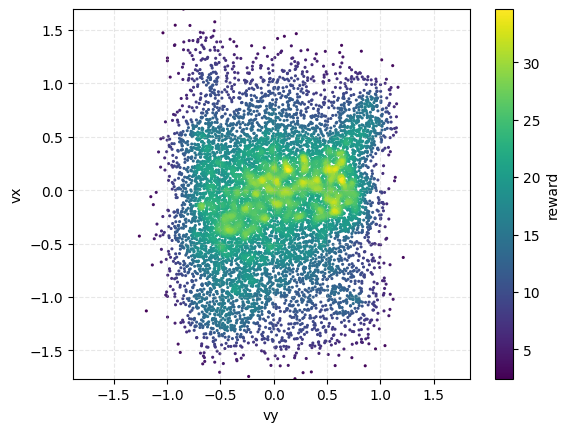

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


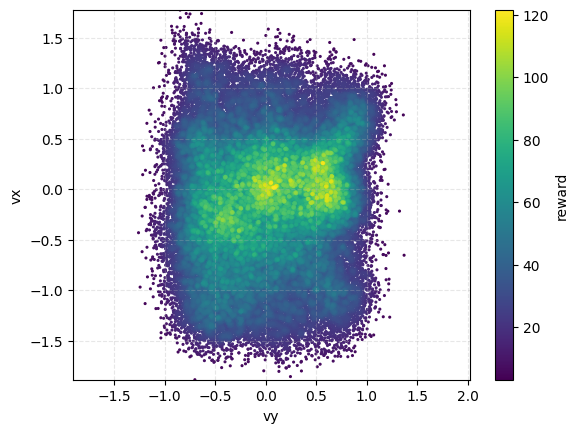

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


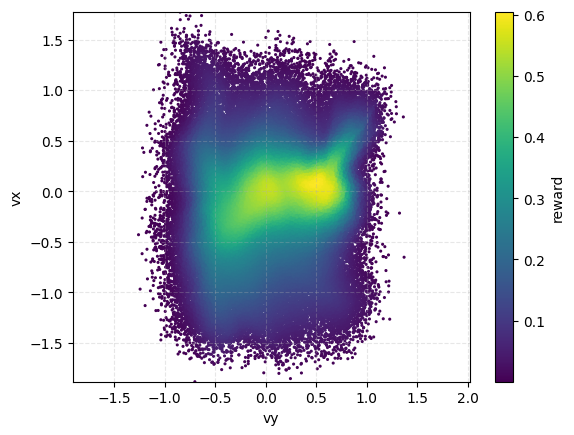

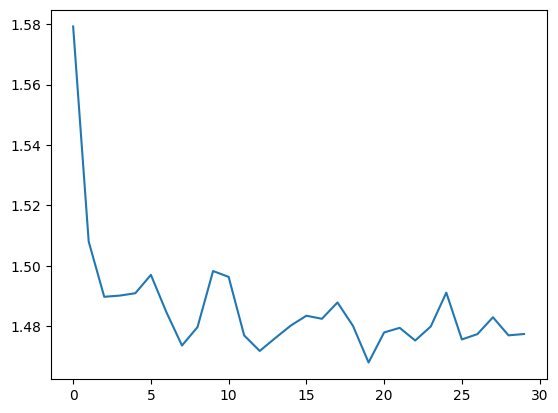

In [130]:
estimator.update(goal_2)
losses = estimator.fit(num_epochs=30, batch_size=256, lr=1e-3)

PLOT_DENSITY(goal_2[:, 1],  # vy
             goal_2[:, 0],  #
             xlabel="vy",
             ylabel="vx",)

PLOT_DENSITY(goal_full_2[:, 1],  # vy
             goal_full_2[:, 0],  #
             xlabel="vy",
             ylabel="vx",)

log_prob = estimator.log_prob(goal_full_2)
prob = torch.exp(log_prob)

PLOT_REWARD(goal_full_2[:, 1],  # vy
            goal_full_2[:, 0],  # vx
            prob,
            xlabel="vy",
            ylabel="vx",)

plt.figure()
plt.plot(losses)
plt.show()

In [122]:
# if losses:
#     print(f"   Initial loss: {losses[0]:.4f}")
#     print(f"   Final loss: {losses[-1]:.4f}")
    
#     # Test sampling from learned distribution
#     print("\n5. Sampling from learned distribution...")
#     num_test_samples = 5000
#     samples = estimator.sample_random(num_test_samples)
#     print(f"   Generated {len(samples)} samples")
#     print(f"   Sample mean: {samples.mean(dim=0)}")
#     print(f"   Sample std: {samples.std(dim=0)}")
    
#     # Test inverse sampling (exploration)
#     print("\n6. Inverse sampling for exploration p(x)^(-beta)...")
#     inverse_samples = estimator.sample_inverse(
#         num_samples=num_test_samples,
#         num_candidates=50000,
#         temperature=1.0,
#     )
#     print(f"   Generated {len(inverse_samples)} inverse samples")
#     print(f"   Inverse sample mean: {inverse_samples.mean(dim=0)}")
#     print(f"   Inverse sample std: {inverse_samples.std(dim=0)}")
    
#     # Compute log probabilities
#     print("\n7. Computing log probabilities...")
#     log_probs_data = estimator.log_prob(goal[:100])
#     log_probs_samples = estimator.log_prob(samples[:100])
#     log_probs_inverse = estimator.log_prob(inverse_samples[:100])
    
#     print(f"   Original data log prob: mean={log_probs_data.mean():.2f}, std={log_probs_data.std():.2f}")
#     print(f"   Random samples log prob: mean={log_probs_samples.mean():.2f}, std={log_probs_samples.std():.2f}")
#     print(f"   Inverse samples log prob: mean={log_probs_inverse.mean():.2f}, std={log_probs_inverse.std():.2f}")
#     print(f"   -> Inverse samples have LOWER probability (good for exploration!)")
    
#     # Visualize results (if matplotlib available)
#     print("\n8. Visualizing results...")
#     try:
#         fig, axes = plt.subplots(2, 2, figsize=(12, 12))
        
#         # Plot original data
#         data_np = goal.cpu().numpy()
#         axes[0, 0].scatter(data_np[:, 0], data_np[:, 1], alpha=0.3, s=5)
#         axes[0, 0].set_title("Original Goal Data")
#         axes[0, 0].set_xlabel("Goal Dim 1")
#         axes[0, 0].set_ylabel("Goal Dim 2")
#         axes[0, 0].grid(True, alpha=0.3)
        
#         # Plot random samples from flow
#         samples_np = samples.cpu().numpy()
#         axes[0, 1].scatter(samples_np[:, 0], samples_np[:, 1], alpha=0.3, s=5, color='green')
#         axes[0, 1].set_title("Random Samples from Flow")
#         axes[0, 1].set_xlabel("Goal Dim 1")
#         axes[0, 1].set_ylabel("Goal Dim 2")
#         axes[0, 1].grid(True, alpha=0.3)
        
#         # Plot inverse samples (exploration)
#         inverse_np = inverse_samples.cpu().numpy()
#         axes[1, 0].scatter(inverse_np[:, 0], inverse_np[:, 1], alpha=0.3, s=5, color='red')
#         axes[1, 0].set_title("Inverse Samples p(x)^(-beta) [Exploration]")
#         axes[1, 0].set_xlabel("Goal Dim 1")
#         axes[1, 0].set_ylabel("Goal Dim 2")
#         axes[1, 0].grid(True, alpha=0.3)
        
#         # Plot training loss
#         axes[1, 1].plot(losses)
#         axes[1, 1].set_title("Training Loss")
#         axes[1, 1].set_xlabel("Epoch")
#         axes[1, 1].set_ylabel("Negative Log-Likelihood")
#         axes[1, 1].grid(True, alpha=0.3)
        
#         plt.tight_layout()
#         plt.savefig("test_normalizing_flow_simple.png", dpi=150)
#         print(f"   Saved visualization to: test_normalizing_flow_simple.png")
        
#     except Exception as e:
#         print(f"   Could not create visualization: {e}")
    
#     print("\n" + "=" * 80)
#     print("Test completed successfully!")
#     print("=" * 80)
#     print("\nKey Results:")
#     print(f"  - Flow successfully fit to {len(goal)} goal samples")
#     print(f"  - Inverse sampling generates samples with {log_probs_inverse.mean():.2f} vs {log_probs_data.mean():.2f} log prob")
#     print(f"  - Lower log prob = under-explored regions = good for exploration!")
#     print(f"  - Beta={estimator.beta} controls exploration intensity")
    
# else:
#     print("   Not enough data to fit!")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Generated 5000 two-moon samples
Data shape: torch.Size([5000, 2])
Data range: X=[-1.15, 2.10], Y=[-0.62, 1.13]


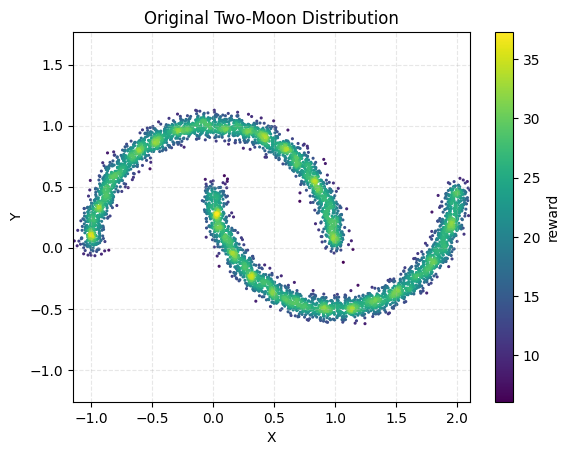

In [78]:
# ========== Two-Moon Distribution Test ==========
from sklearn.datasets import make_moons

# 生成 two-moon 数据
n_samples = 5000
X_moon, _ = make_moons(n_samples=n_samples, noise=0.05, random_state=42)
X_moon = torch.tensor(X_moon, dtype=torch.float32).to(device)

print(f"Generated {len(X_moon)} two-moon samples")
print(f"Data shape: {X_moon.shape}")
print(f"Data range: X=[{X_moon[:, 0].min():.2f}, {X_moon[:, 0].max():.2f}], Y=[{X_moon[:, 1].min():.2f}, {X_moon[:, 1].max():.2f}]")

# 可视化原始 two-moon 数据
PLOT_DENSITY(X_moon[:, 0], X_moon[:, 1], 
             xlabel="X", ylabel="Y", 
             title="Original Two-Moon Distribution")


训练 NF 模型...


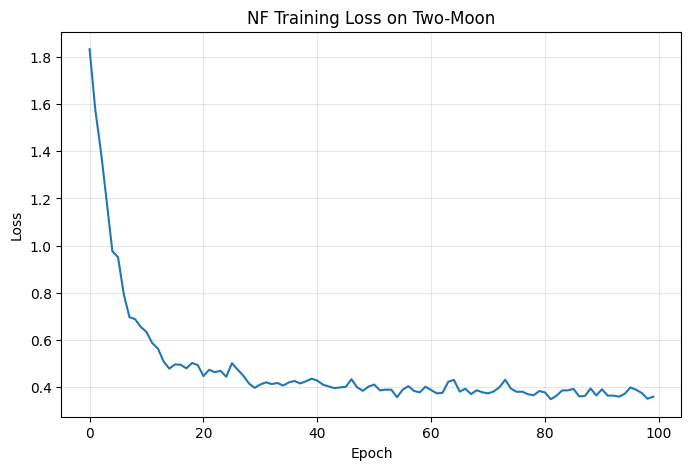

训练完成！初始损失: 1.8332, 最终损失: 0.3592


In [84]:
# 创建新的 NF estimator 用于 two-moon 数据
estimator_moon = GoalDensityEstimator(
    goal_dim=2,
    num_layers=10,
    hidden_dim=64,
    beta=2.0,
    device=device,
)

# 训练 NF 模型
print("\n训练 NF 模型...")
estimator_moon.update(X_moon)
losses_moon = estimator_moon.fit(num_epochs=100, batch_size=256, lr=1e-3)

# 绘制训练损失
plt.figure(figsize=(8, 5))
plt.plot(losses_moon)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NF Training Loss on Two-Moon")
plt.grid(True, alpha=0.3)
plt.show()

print(f"训练完成！初始损失: {losses_moon[0]:.4f}, 最终损失: {losses_moon[-1]:.4f}")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


原始数据概率统计: mean=0.8197, std=0.3288
Log概率统计: mean=-0.3503, std=0.6998


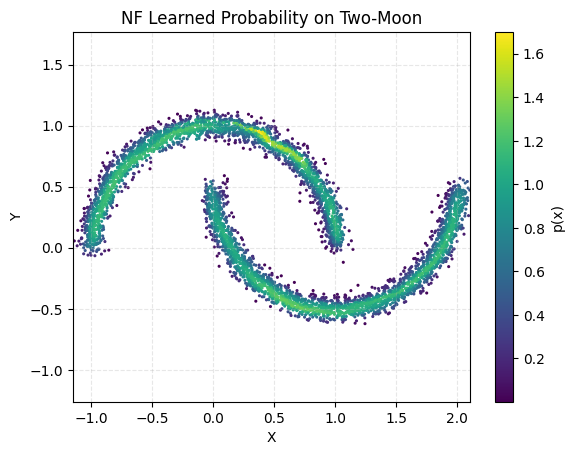

In [85]:
# 测试1: 计算原始数据的概率密度
log_prob_moon = estimator_moon.log_prob(X_moon)
prob_moon = torch.exp(log_prob_moon)

PLOT_REWARD(X_moon[:, 0], X_moon[:, 1], prob_moon,
            xlabel="X", ylabel="Y",
            title="NF Learned Probability on Two-Moon",
            bar="p(x)")

print(f"原始数据概率统计: mean={prob_moon.mean():.4f}, std={prob_moon.std():.4f}")
print(f"Log概率统计: mean={log_prob_moon.mean():.4f}, std={log_prob_moon.std():.4f}")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



从学习到的分布中采样...
采样点概率统计: mean log p(x)=-0.3904, std=0.7467


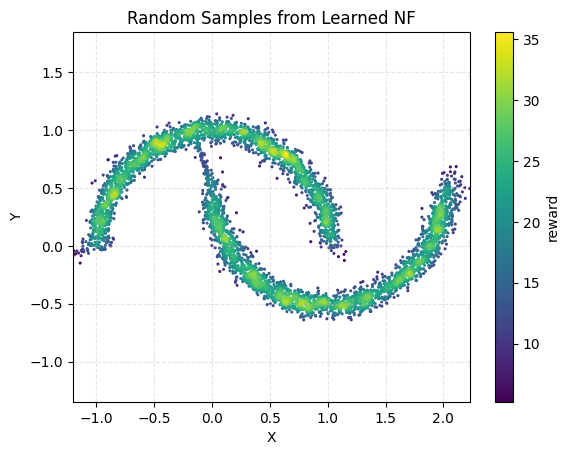

In [86]:
# 测试2: 从学习到的分布中随机采样
print("\n从学习到的分布中采样...")
samples_moon = estimator_moon.sample_random(5000)

PLOT_DENSITY(samples_moon[:, 0], samples_moon[:, 1],
             xlabel="X", ylabel="Y",
             title="Random Samples from Learned NF")

# 计算采样点的概率
log_prob_samples = estimator_moon.log_prob(samples_moon)
print(f"采样点概率统计: mean log p(x)={log_prob_samples.mean():.4f}, std={log_prob_samples.std():.4f}")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



逆采样测试 p(x)^(-beta)...
逆采样点概率统计: mean log p(x)=-1.7117, std=1.2626
对比: 原始数据 -0.3503 vs 逆采样 -1.7117
-> 逆采样倾向于低概率区域，适合探索！


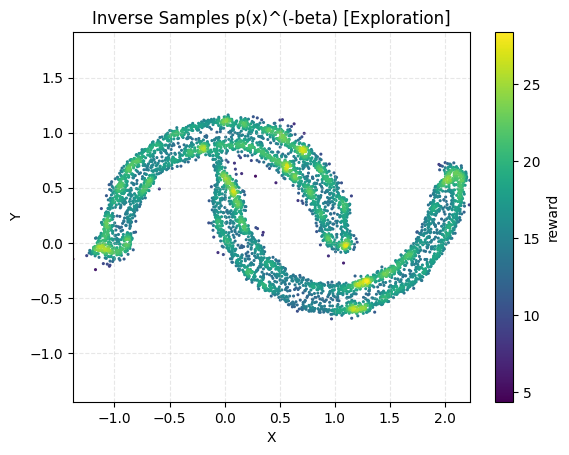

In [87]:
# 测试3: 逆采样 p(x)^(-beta) 用于探索低概率区域
print("\n逆采样测试 p(x)^(-beta)...")
inverse_samples_moon = estimator_moon.sample_inverse(
    num_samples=5000,
    num_candidates=50000,
    temperature=1.0,
)

PLOT_DENSITY(inverse_samples_moon[:, 0], inverse_samples_moon[:, 1],
             xlabel="X", ylabel="Y",
             title="Inverse Samples p(x)^(-beta) [Exploration]")

# 计算逆采样点的概率
log_prob_inverse = estimator_moon.log_prob(inverse_samples_moon)
print(f"逆采样点概率统计: mean log p(x)={log_prob_inverse.mean():.4f}, std={log_prob_inverse.std():.4f}")
print(f"对比: 原始数据 {log_prob_moon.mean():.4f} vs 逆采样 {log_prob_inverse.mean():.4f}")
print(f"-> 逆采样倾向于低概率区域，适合探索！")

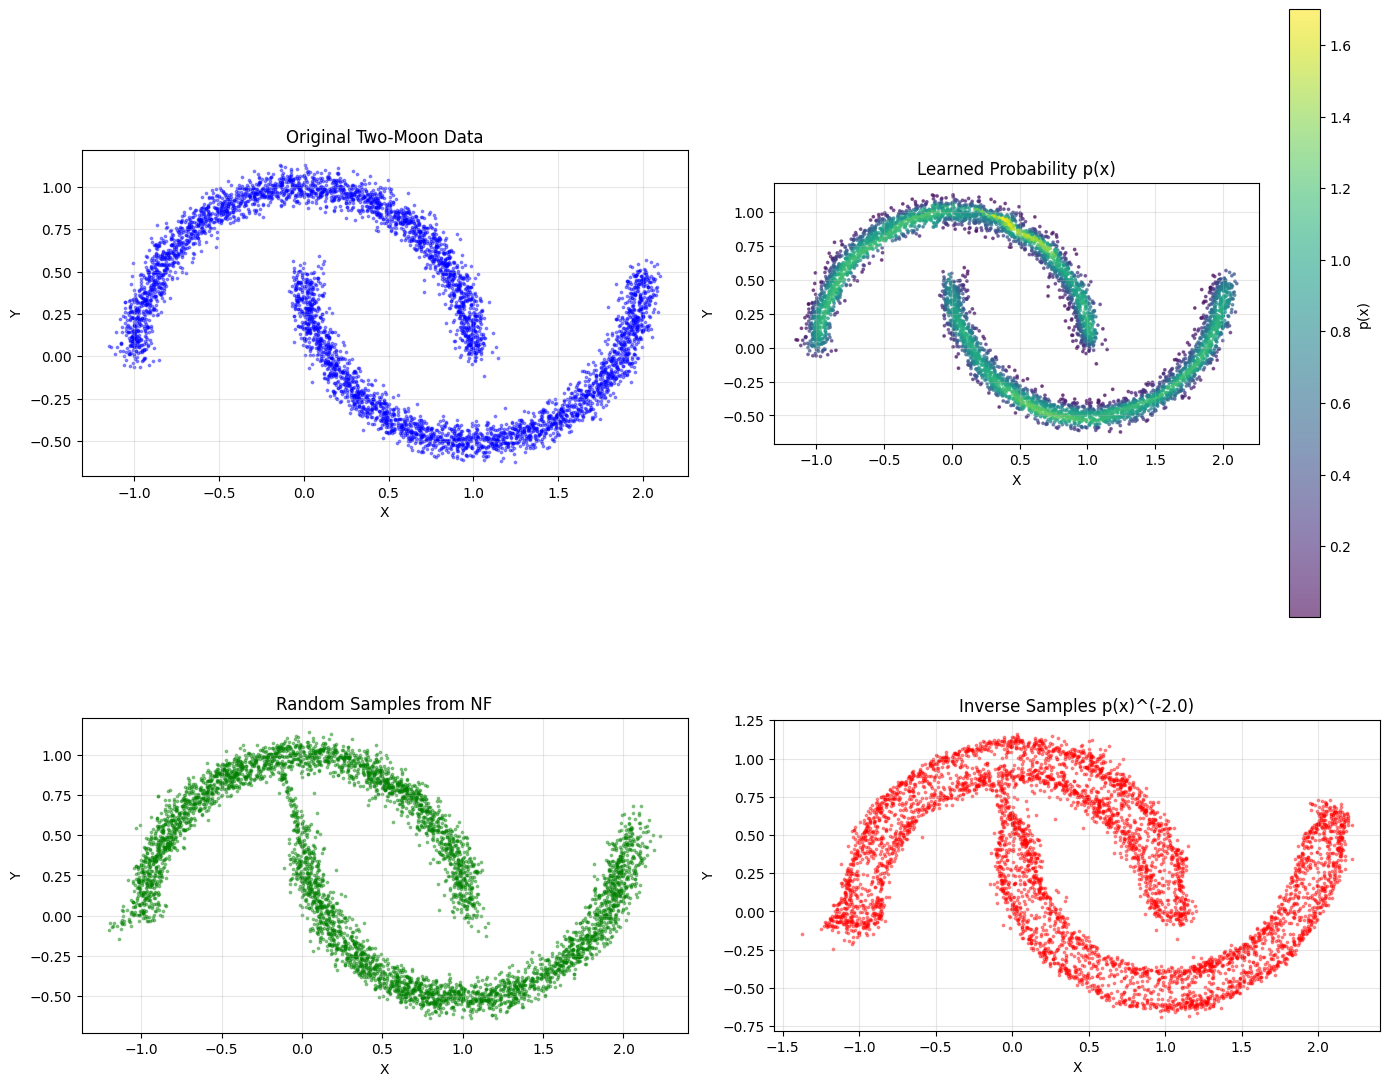


Two-Moon NF 测试总结:
✓ 训练损失: 1.8332 → 0.3592
✓ 随机采样能够重现 two-moon 分布
✓ 逆采样倾向于低密度区域（log p: -0.35 vs -1.71）
✓ Beta=2.0 控制探索强度


In [88]:
# 测试4: 综合对比可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 子图1: 原始 two-moon 数据
X_np = X_moon.cpu().numpy()
axes[0, 0].scatter(X_np[:, 0], X_np[:, 1], alpha=0.4, s=3, c='blue')
axes[0, 0].set_title("Original Two-Moon Data", fontsize=12)
axes[0, 0].set_xlabel("X")
axes[0, 0].set_ylabel("Y")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_aspect('equal')

# 子图2: NF学习到的概率密度
prob_np = prob_moon.cpu().numpy()
scatter = axes[0, 1].scatter(X_np[:, 0], X_np[:, 1], 
                             c=prob_np, cmap='viridis', alpha=0.6, s=3)
axes[0, 1].set_title("Learned Probability p(x)", fontsize=12)
axes[0, 1].set_xlabel("X")
axes[0, 1].set_ylabel("Y")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_aspect('equal')
plt.colorbar(scatter, ax=axes[0, 1], label='p(x)')

# 子图3: 从NF随机采样
samples_np = samples_moon.cpu().numpy()
axes[1, 0].scatter(samples_np[:, 0], samples_np[:, 1], alpha=0.4, s=3, c='green')
axes[1, 0].set_title("Random Samples from NF", fontsize=12)
axes[1, 0].set_xlabel("X")
axes[1, 0].set_ylabel("Y")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_aspect('equal')

# 子图4: 逆采样（探索）
inverse_np = inverse_samples_moon.cpu().numpy()
axes[1, 1].scatter(inverse_np[:, 0], inverse_np[:, 1], alpha=0.4, s=3, c='red')
axes[1, 1].set_title(f"Inverse Samples p(x)^(-{estimator_moon.beta})", fontsize=12)
axes[1, 1].set_xlabel("X")
axes[1, 1].set_ylabel("Y")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Two-Moon NF 测试总结:")
print("="*60)
print(f"✓ 训练损失: {losses_moon[0]:.4f} → {losses_moon[-1]:.4f}")
print(f"✓ 随机采样能够重现 two-moon 分布")
print(f"✓ 逆采样倾向于低密度区域（log p: {log_prob_moon.mean():.2f} vs {log_prob_inverse.mean():.2f}）")
print(f"✓ Beta={estimator_moon.beta} 控制探索强度")
print("="*60)